In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Loading the  Dataset

df = pd.read_csv("ev_vehicle_battery_preprocessed_dataset.csv")

# Convert all variations into clean binary labels
df['Battery_Status'] = df['Battery_Status'].str.strip().str.lower()

df['Battery_Status'] = df['Battery_Status'].replace({
    'healthy': 1,
    'unhealthy': 0
})



/tmp/ipykernel_6232/482826223.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Battery_Status'] = df['Battery_Status'].replace({



=== MODEL COMPARISON ===


/home/user/anaconda3/envs/dsp_lab/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
Accuracy: 0.988895382817066
F1 Score: 0.9907271839921913

KNN
Accuracy: 0.9696084161309176
F1 Score: 0.9744597249508841

SVM
Accuracy: 0.9164231443600234
F1 Score: 0.9289617486338798

Decision Tree
Accuracy: 0.9959088252483927
F1 Score: 0.9965903555772041

Random Forest
Accuracy: 0.9994155464640561
F1 Score: 0.9995129079396006

=== FINAL MODEL: XGBOOST ===
Accuracy : 0.9994155464640561
Precision: 0.9995131450827653
Recall   : 0.9992700729927007
F1 Score : 0.9993912238748405

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       685
           1       1.00      1.00      1.00      1026

    accuracy                           1.00      1711
   macro avg       1.00      1.00      1.00      1711
weighted avg       1.00      1.00      1.00      1711


Confusion Matrix:
 [[ 684    1]
 [   0 1026]]


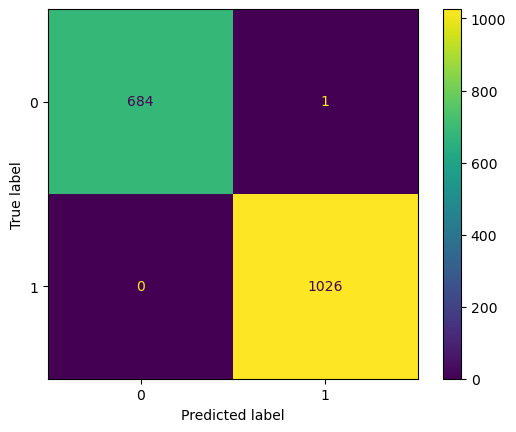


Class Meaning:
0 -> Unhealthy
1 -> Healthy


In [7]:


import pandas as pd

# -------- FEATURES & TARGET --------
X = df.drop(columns=['SoH_Percent', 'Battery_Status'])
y = df['Battery_Status']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)


X = pd.get_dummies(X, drop_first=True)


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

from collections import Counter
counter = Counter(y_train)
total = sum(counter.values())
class_weights = {cls: total/count for cls, count in counter.items()}
sample_weights = [class_weights[label] for label in y_train]


from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb = xgb_model.predict(X_test)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200)
}

print("\n=== MODEL COMPARISON ===")

for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    y_pred_temp = mdl.predict(X_test)
    
    from sklearn.metrics import accuracy_score, f1_score
    
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred_temp))
    print("F1 Score:", f1_score(y_test, y_pred_temp))




from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("\n=== FINAL MODEL: XGBOOST ===")

accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred_xgb, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred_xgb, average='macro', zero_division=0)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, zero_division=0))

#  CONFUSION MATRIX 
cm = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:\n", cm)

import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


print("\nClass Meaning:")
print("0 -> Unhealthy")
print("1 -> Healthy")